In [1]:
!python -V

Python 3.14.2


In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pickle

In [4]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

In [5]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("nyc-taxi-experiment")

2026/02/22 23:03:54 INFO mlflow.tracking.fluent: Experiment with name 'nyc-taxi-experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1771781634149, experiment_id='1', last_update_time=1771781634149, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}, workspace='default'>

In [6]:
def read_dataframe(filename):
    df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [7]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-02.parquet')

In [8]:
len(df_train), len(df_val)

(59603, 66097)

In [9]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

train_dicts = df_train[categorical + numerical].to_dict(orient='records')

val_dicts = df_val[categorical + numerical].to_dict(orient='records')

In [10]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [11]:
pipeline = make_pipeline(
    DictVectorizer(),
    LinearRegression()
)

pipeline.fit(train_dicts, y_train)
y_pred = pipeline.predict(val_dicts)

In [12]:
with mlflow.start_run():
    mlflow.log_params({
        "categorical": categorical,
        "numerical": numerical,
        "model_type": "LinearRegression"
    })
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    print("RMSE:", rmse)
    mlflow.log_metric("rmse", rmse)
    
    with open('lin_reg.bin', 'wb') as f_out:
        pickle.dump(pipeline, f_out)
        
    mlflow.log_artifact('lin_reg.bin')
    mlflow.sklearn.log_model(pipeline, name='model')

2026/02/22 23:03:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


RMSE: 8.193832538948914


2026/02/22 23:03:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run caring-pug-154 at: http://localhost:5000/#/experiments/1/runs/08fd9c49b24746f6a771479571c9c54f
🧪 View experiment at: http://localhost:5000/#/experiments/1


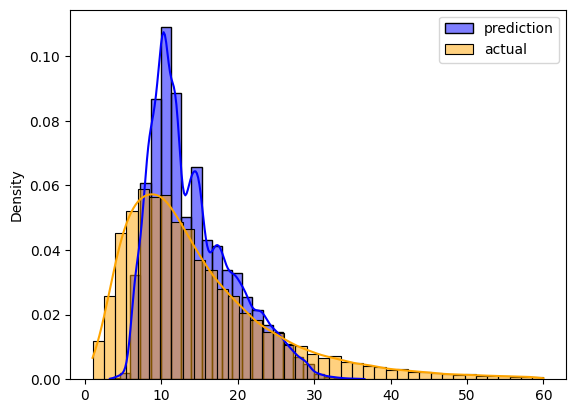

In [13]:
sns.histplot(y_pred, kde=True, stat="density", color='blue', bins=25, label='prediction')
sns.histplot(y_val, kde=True, stat="density", color='orange', bins=40, label='actual')

plt.legend()

In [ ]:
model = mlflow.pyfunc.load_model("models:/trip_duration@staging")
trip = [{
    "PULocationID": "43",
    "DOLocationID": "238",
    "trip_distance": 1.16
}]

model.predict(trip)

array([8.78925931])